# PCA on V-block (30 / 60 / 90 components)

Uses `train_transaction.csv` at the path below. **Colab:** run `from google.colab import drive` then `drive.mount('/content/drive')` if needed.

Fits **PCA up to 90 components** on `V1`–`V339` (median-imputed, standardized), prints **cumulative explained variance** at **30, 60, and 90** PCs, and plots per-component + cumulative (1–90).

In [1]:
import os
from pathlib import Path

# Target directory based on the subsequent code cell's requirements
target_path = Path("/content/drive/MyDrive/ieee_cis_fraud/team1_member2/raw/train_transaction.csv")
target_path.parent.mkdir(parents=True, exist_ok=True)

# Google Drive link details
url = "https://drive.google.com/file/d/1tfRlffeRPLScPS58dwTYq-_cCXloYIor/view?usp=drive_link"
file_id = "1tfRlffeRPLScPS58dwTYq-_cCXloYIor"
direct_download_url = f"https://drive.google.com/uc?id={file_id}"

print(f"Downloading dataset to {target_path}...")

try:
    import gdown
    gdown.download(direct_download_url, str(target_path), quiet=False, fuzzy=True)
    print("\nDownload complete.")
except ImportError:
    print("Installing gdown...")
    !pip install -q gdown
    import gdown
    gdown.download(direct_download_url, str(target_path), quiet=False, fuzzy=True)
    print("\nDownload complete.")

Downloading...
From (original): https://drive.google.com/uc?id=1tfRlffeRPLScPS58dwTYq-_cCXloYIor
From (redirected): https://drive.google.com/uc?id=1tfRlffeRPLScPS58dwTYq-_cCXloYIor&confirm=t&uuid=e8b92829-84b7-436f-a8fc-531ca5320c00
To: /content/drive/MyDrive/ieee_cis_fraud/team1_member2/raw/train_transaction.csv
100%|██████████| 683M/683M [00:09<00:00, 74.5MB/s]


Download complete.


PCA n_components=90 (first 90 PCs of standardized V-block)
  cumulative explained variance @ 30 PCs: 0.7949
  cumulative explained variance @ 60 PCs: 0.9023
  cumulative explained variance @ 90 PCs: 0.9485
  cumulative @ 90 PCs (all fitted): 0.9485
Per-component ratio (first 5): [0.180165, 0.10384, 0.058889, 0.040852, 0.033111] ...


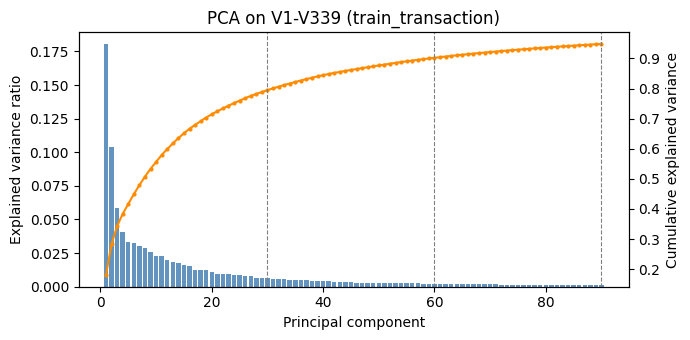

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

TRAIN_CSV = Path("/content/drive/MyDrive/ieee_cis_fraud/team1_member2/raw/train_transaction.csv")
N_COMPONENTS_MAX = 90
CHECK_KS = (30, 60, 90)
RANDOM_SEED = 42

V_COLS = [f"V{i}" for i in range(1, 340)]

assert TRAIN_CSV.is_file(), f"Missing: {TRAIN_CSV} — mount Drive and check the path."

X = pd.read_csv(TRAIN_CSV, usecols=V_COLS)
assert X.shape[1] == 339, X.shape

X_imp = SimpleImputer(strategy="median").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imp)
pca = PCA(n_components=N_COMPONENTS_MAX, random_state=RANDOM_SEED)
pca.fit(X_scaled)

ev = np.asarray(pca.explained_variance_ratio_)
cum = np.cumsum(ev)
print(f"PCA n_components={N_COMPONENTS_MAX} (first {N_COMPONENTS_MAX} PCs of standardized V-block)")
for k in CHECK_KS:
    print(f"  cumulative explained variance @ {k} PCs: {cum[k - 1]:.4f}")
print(f"  cumulative @ {N_COMPONENTS_MAX} PCs (all fitted): {cum[-1]:.4f}")
print("Per-component ratio (first 5):", np.round(ev[:5], 6).tolist(), "...")

fig, ax = plt.subplots(figsize=(7, 3.5))
n = N_COMPONENTS_MAX
ax.bar(range(1, n + 1), ev, color="steelblue", alpha=0.85, label="per PC")
ax2 = ax.twinx()
ax2.plot(range(1, n + 1), cum, color="darkorange", marker="o", ms=2, lw=1.5, label="cumulative")
for k in CHECK_KS:
    ax2.axvline(k, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax2.set_ylabel("Cumulative explained variance")
ax.set_title("PCA on V1-V339 (train_transaction)")
fig.tight_layout()
plt.show()